In [27]:
!pip install pandas matplotlib -q

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data/raw/shopping.csv')
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


---
## Question 1: Do male, female, and non-binary shoppers differ in average purchase amount, and which gender segment drives the most total revenue?

In [18]:
gender_revenue = df.groupby('Gender')['Purchase Amount (USD)'].agg(
    Average_Spend='mean',
    Total_Revenue='sum',
    Transaction_Count='count'
).round(2).sort_values('Total_Revenue', ascending=False)

print(gender_revenue)

            Average_Spend  Total_Revenue  Transaction_Count
Gender                                                     
Male                38.58       76032.29               1971
Female              38.87       73620.71               1894
Non-binary          37.41        1309.49                 35


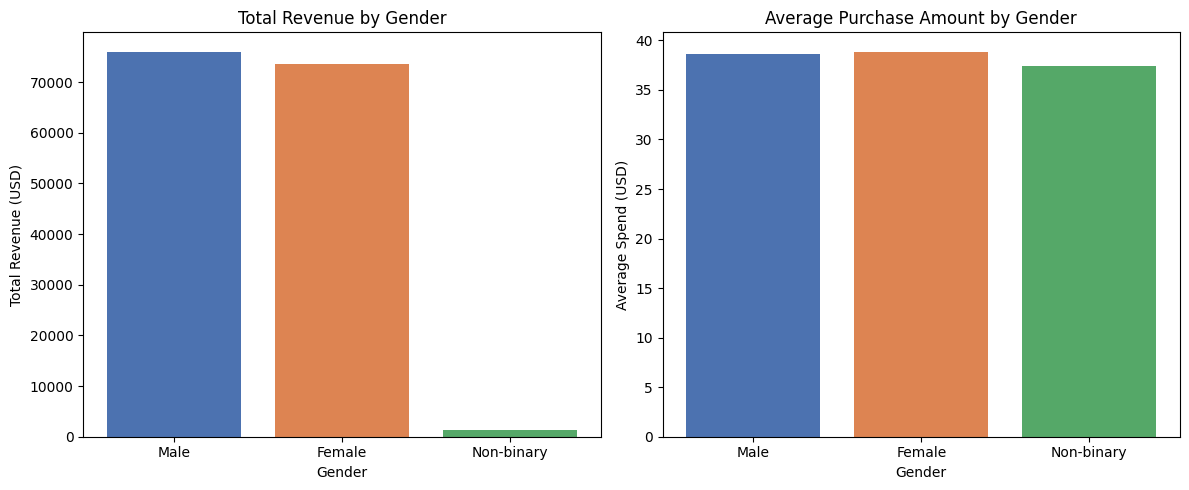

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(gender_revenue.index, gender_revenue['Total_Revenue'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Total Revenue by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Total Revenue (USD)')

axes[1].bar(gender_revenue.index, gender_revenue['Average_Spend'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Average Purchase Amount by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Average Spend (USD)')

plt.tight_layout()
plt.show()

**Interpretation:** Male shoppers generate the highest total revenue at $76,032, driven primarily by their larger share of the customer 
base (1,971 transactions) rather than higher individual spending. Female shoppers follow closely at $73,621, with a slightly higher average 
spend per transaction ($38.87 vs. $38.58). Non-binary shoppers represent a very small segment (35 transactions) with a marginally lower average 
spend of $37.41. Overall, gender has minimal effect on individual purchase amount — the differences are under $1.50 — suggesting FlashFash 
should prioritize growing the customer base broadly rather than targeting one gender segment for higher spend.

---
## Question 2: Which U.S. states generate the highest total purchase volume, and is there a geographic concentration of high-value customers?

In [20]:
state_revenue = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

top10_states = state_revenue.head(10)
print(top10_states.round(2))

Location
California       3474.55
Nebraska         3195.73
Delaware         3140.87
West Virginia    3127.54
Idaho            3097.35
Indiana          3086.46
Montana          3077.97
Maryland         3048.55
New York         3039.72
Nevada           3032.91
Name: Purchase Amount (USD), dtype: float64


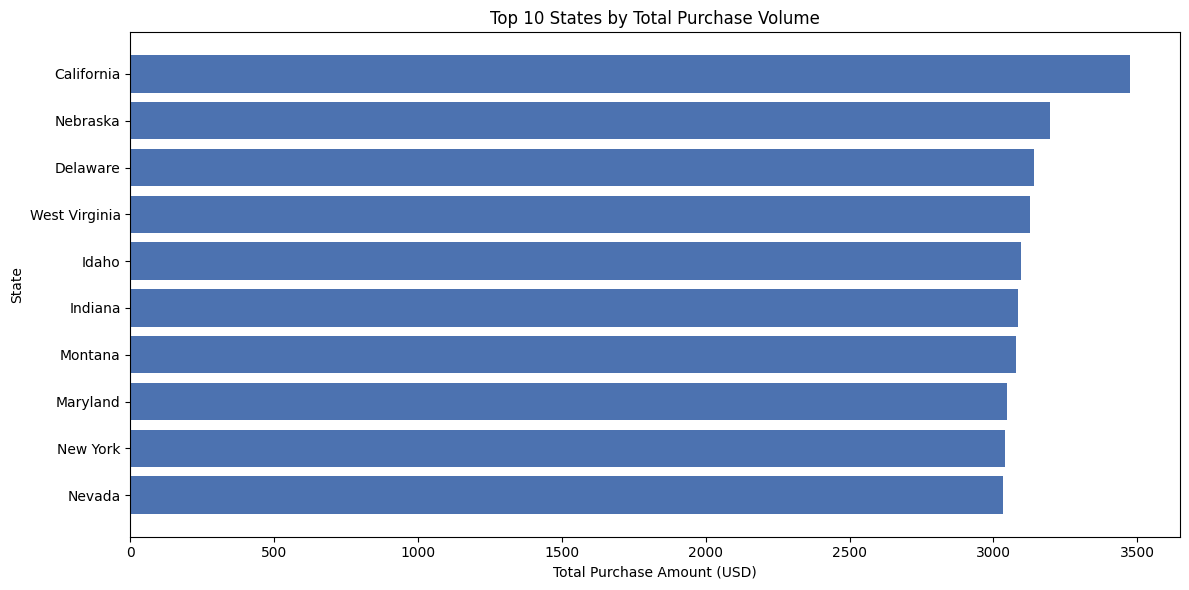

In [21]:
plt.figure(figsize=(12, 6))
plt.barh(top10_states.index[::-1], top10_states.values[::-1], color='#4C72B0')
plt.title('Top 10 States by Total Purchase Volume')
plt.xlabel('Total Purchase Amount (USD)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Interpretation:** California leads all states with $3,474 in total purchase volume, followed by Nebraska and Delaware. Notably, the geographic spread is relatively even — the top 10 states span all regions of the country, including the Mountain West (Montana, Idaho, Nevada), the Midwest (Nebraska, Indiana), and the Mid-Atlantic (Delaware, Maryland, West Virginia). This suggests FlashFash's American customer base is nationally distributed rather than concentrated in major coastal markets, which has implications for logistics infrastructure and regional marketing spend.

---
## Question 3: Are customers who use express or next-day shipping more likely to have made more previous purchases than those using standard shipping?

In [22]:
premium_shipping = df[df['Shipping Type'].isin(['Express', 'Next Day Air'])]
standard_shipping = df[df['Shipping Type'] == 'Standard']

print(f"Premium shipping customers — Avg previous purchases: {premium_shipping['Previous Purchases'].mean():.2f}")
print(f"Standard shipping customers — Avg previous purchases: {standard_shipping['Previous Purchases'].mean():.2f}")
print(f"\nPremium shipping count: {len(premium_shipping)}")
print(f"Standard shipping count: {len(standard_shipping)}")

Premium shipping customers — Avg previous purchases: 5.93
Standard shipping customers — Avg previous purchases: 5.86

Premium shipping count: 563
Standard shipping count: 2162


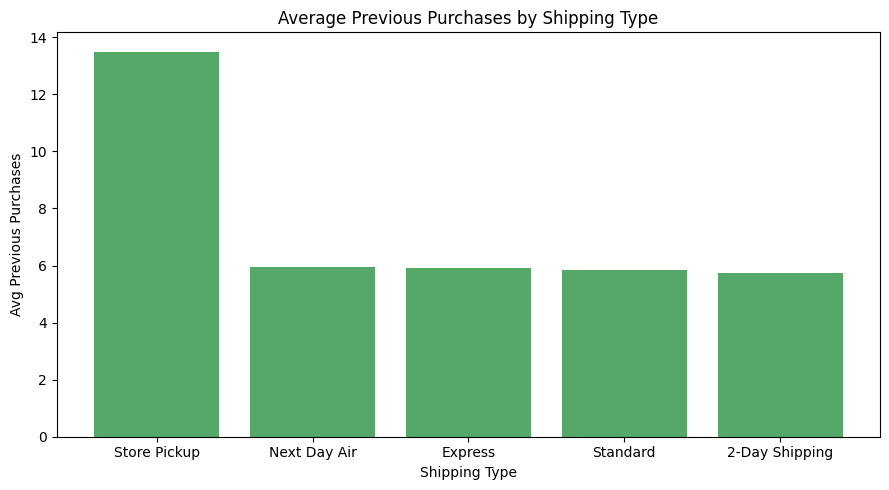

In [23]:
shipping_prev = df.groupby('Shipping Type')['Previous Purchases'].mean().sort_values(ascending=False).round(2)

plt.figure(figsize=(9, 5))
plt.bar(shipping_prev.index, shipping_prev.values, color='#55A868')
plt.title('Average Previous Purchases by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Avg Previous Purchases')
plt.tight_layout()
plt.show()

**Interpretation:** Premium shipping customers (Express and Next Day Air) averaged 5.93 previous purchases compared to 5.86 for standard shipping customers — a difference of less than 0.1. This finding suggests that shipping preference is not strongly correlated with customer loyalty or purchase history in this dataset. FlashFash should be cautious about assuming that offering premium shipping upgrades will attract or retain its highest-frequency buyers, and may want to explore other loyalty signals such as payment method or promo code usage instead.

---
## Question 4: Which payment methods are associated with the highest average spend, and does payment method correlate with promo code usage?

In [24]:
payment_spend = df.groupby('Payment Method')['Purchase Amount (USD)'].mean().round(2).sort_values(ascending=False)
print('Average Spend by Payment Method:')
print(payment_spend)

Average Spend by Payment Method:
Payment Method
Bank Transfer    42.72
Debit Card       38.83
PayPal           38.75
Credit Card      38.61
Venmo            38.60
Cash             37.17
Name: Purchase Amount (USD), dtype: float64


In [25]:
promo_pivot = pd.pivot_table(
    df,
    values='Purchase Amount (USD)',
    index='Payment Method',
    columns='Promo Code Used',
    aggfunc='mean'
).round(2)

print('Average Spend by Payment Method and Promo Code Usage:')
print(promo_pivot)

Average Spend by Payment Method and Promo Code Usage:
Promo Code Used     No    Yes
Payment Method               
Bank Transfer    32.06  55.52
Cash             29.80  48.23
Credit Card      29.93  49.88
Debit Card       30.43  50.06
PayPal           30.35  49.89
Venmo            29.98  50.34


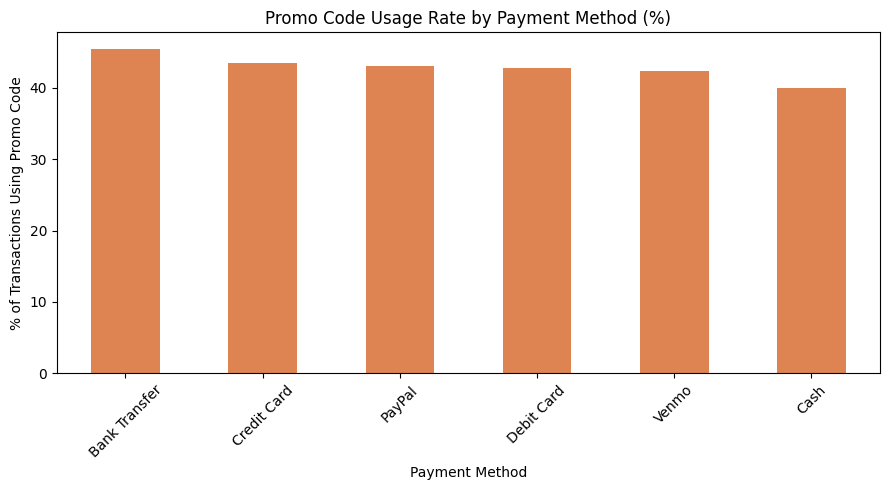

In [26]:
promo_rate = pd.crosstab(df['Payment Method'], df['Promo Code Used'], normalize='index').round(3) * 100

promo_rate['Yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(9, 5),
    color='#DD8452',
    title='Promo Code Usage Rate by Payment Method (%)'
)
plt.xlabel('Payment Method')
plt.ylabel('% of Transactions Using Promo Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Bank Transfer customers have the highest average spend at $42.72, though this method represents only 11 transactions and should be interpreted cautiously. Among the four high-volume payment methods (Credit Card, Debit Card, PayPal, Venmo), average spend is remarkably consistent — ranging from $38.60 to $38.83 — suggesting payment method alone does not drive purchase size. Promo code usage rates are also nearly uniform across all methods, hovering between 42–45%, which indicates that discount-seeking behavior is evenly distributed across payment types rather than concentrated in any one segment.